1)create simple deep learning(10) layers;
2)Demonstrate vanishing gradient and exploding GD
3)Demonstrate symmetry problem
4)Implement weight Initialization strategies
I)Xavier
II)He Initialization test diff optimizers basic program

# **Demonstrate vanishing gradient with sigmoid**

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1127 - loss: 2.3370
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1127 - loss: 2.3016
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1127 - loss: 2.3016
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1127 - loss: 2.3016
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1127 - loss: 2.3016
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1127 - loss: 2.3016
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1127 - loss: 2.3016
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1127 - loss: 2.3016
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1127 - loss: 2.3016
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1127 - loss: 2.3016
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1127 - loss: 2.3016
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/st

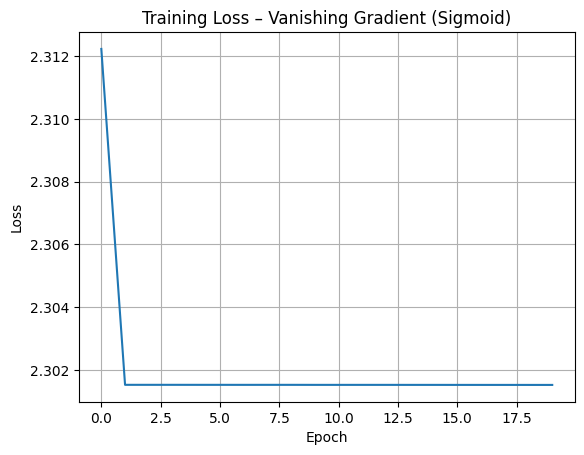

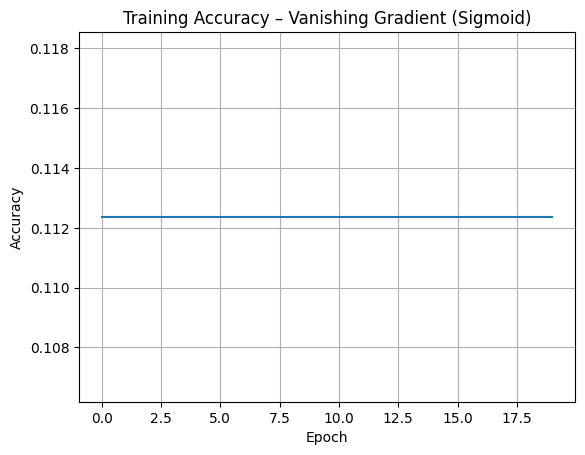

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.initializers import RandomNormal
from keras.optimizers import SGD

tf.random.set_seed(42)
np.random.seed(42)
(X_train, y_train), _ = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_train = X_train.reshape(-1, 784)

model = Sequential()
model.add(Dense(128,activation="sigmoid",input_shape=(784,),kernel_initializer=RandomNormal(mean=0.0, stddev=0.1)))


for _ in range(9):
  model.add(Dense(64,activation="sigmoid",kernel_initializer=RandomNormal(mean=0.0, stddev=0.001)))

model.add(Dense(10, activation="softmax"))

model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(X_train,y_train,epochs=20,batch_size=128,verbose=1)

plt.figure()
plt.plot(history.history["loss"])
plt.title("Training Loss – Vanishing Gradient (Sigmoid)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history["accuracy"])
plt.title("Training Accuracy – Vanishing Gradient (Sigmoid)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


# **Exploding gradient descent when high learning**

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0983 - loss: nan
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0998 - loss: nan
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0998 - loss: nan
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0998 - loss: nan
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0998 - loss: nan
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0998 - loss: nan
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0998 - loss: nan
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0998 - loss: nan
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0998 - loss: nan
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0998 - loss: nan
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0998 - loss: nan
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0998 - loss: nan
E

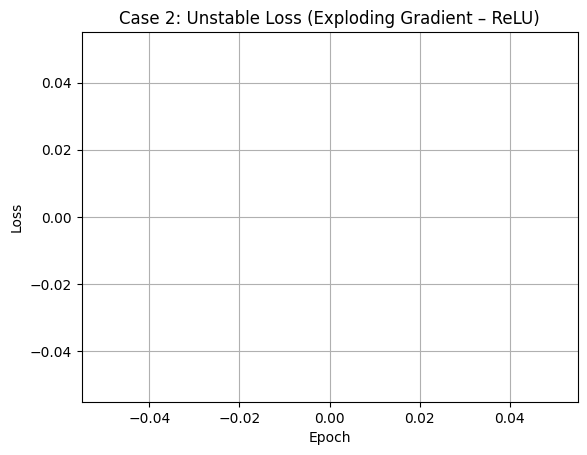

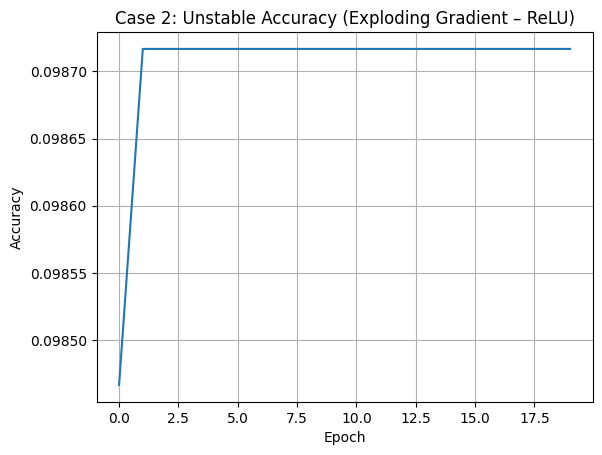

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.initializers import RandomNormal
from keras.optimizers import SGD

tf.random.set_seed(42)
np.random.seed(42)

(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype("float32") / 255.0
X_train = X_train.reshape(-1, 784)

model = Sequential()
model.add(Dense(128, activation="relu", input_shape=(784,),
                kernel_initializer=RandomNormal(0.0, 0.6)))
for _ in range(9):
    model.add(Dense(64, activation="relu",
                    kernel_initializer=RandomNormal(0.0, 0.6)))
model.add(Dense(10, activation="softmax"))

model.compile(
    optimizer=SGD(learning_rate=0.03),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(X_train, y_train, epochs=20, batch_size=128, verbose=1)

plt.figure()
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Exploding Gradient – ReLU)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Exploding Gradient – ReLU)")
plt.grid(True)
plt.show()


# **ADAM AND SGD**


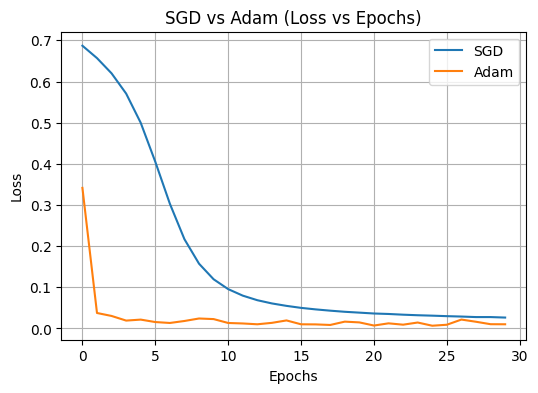

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split


np.random.seed(42)
X = np.random.randn(2000, 2)
y = (X[:,0] + X[:,1] > 0).astype(int)
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42)

def build_model():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(2,)))
    for _ in range(4):
        model.add(Dense(64, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model

sgd_model = build_model()
sgd_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='binary_crossentropy'
)
hist_sgd = sgd_model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)


adam_model = build_model()
adam_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)
hist_adam = adam_model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)


plt.figure(figsize=(6,4))
plt.plot(hist_sgd.history['loss'], label='SGD')
plt.plot(hist_adam.history['loss'], label='Adam')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("SGD vs Adam (Loss vs Epochs)")
plt.legend()
plt.grid()
plt.show()

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7769 - loss: 0.8855 - val_accuracy: 0.9487 - val_loss: 0.1821
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9419 - loss: 0.2013 - val_accuracy: 0.9652 - val_loss: 0.1262
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9586 - loss: 0.1419 - val_accuracy: 0.9697 - val_loss: 0.1090
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9707 - loss: 0.0992 - val_accuracy: 0.9740 - val_loss: 0.0900
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9773 - loss: 0.0755 - val_accuracy: 0.9767 - val_loss: 0.0798
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9830 - loss: 0.0581 - val_accuracy: 0.9767 - val_loss: 0.0755
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0469 - val_accuracy: 0.9787 - val_loss: 0.0750
Epoch 8/10
 651/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9902 - loss: 0.0377

# **Symmetry Problem**

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        2,
        activation='sigmoid',
        kernel_initializer='zeros',
        input_shape=(2,)
    ),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='sgd',
    loss='binary_crossentropy'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

# **Xavier (Glorot) Initializer (More Stable)**

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.1067 - loss: 2.3169
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1165 - loss: 2.2695
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2043 - loss: 1.9328
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2068 - loss: 1.9100
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2243 - loss: 1.8334
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3979 - loss: 1.3697
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5140 - loss: 1.1573
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6715 - loss: 0.9073
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7083 - loss: 0.7788
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7204 - loss: 0.7118
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7367 - loss: 0.6584
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/ste

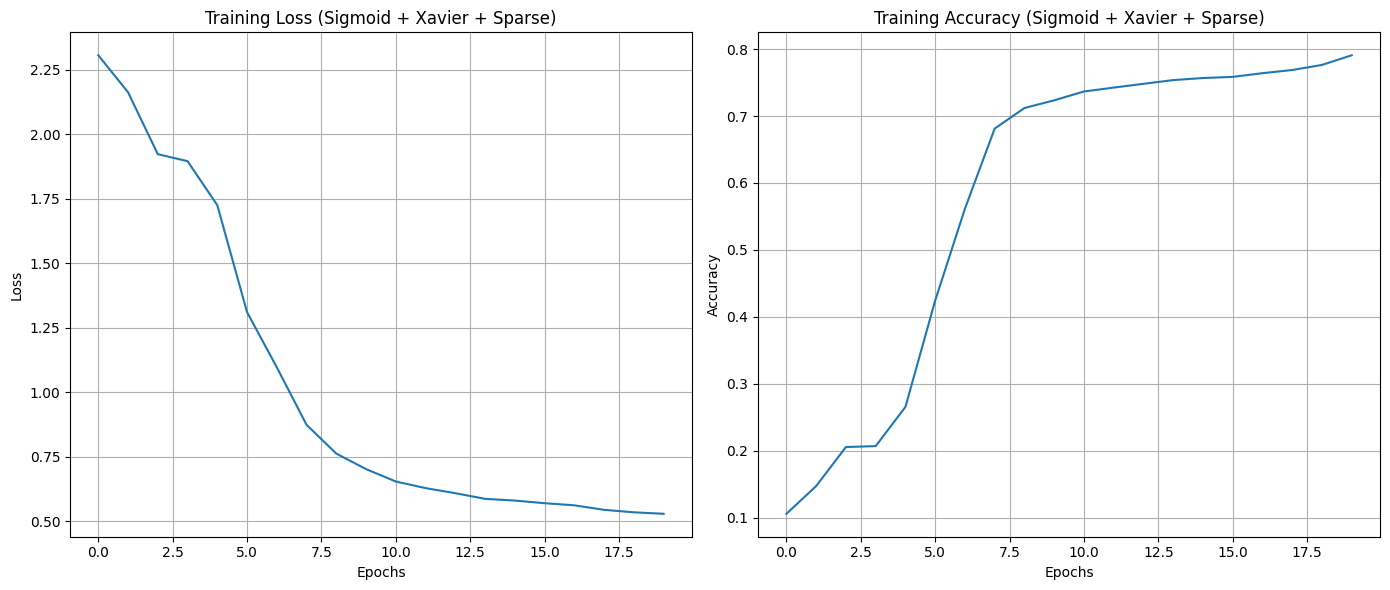

In [ ]:
# Xavier using MNIST (Sigmoid + Sparse Categorical, 10 Hidden Layers) – NO function / NO definition

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import mnist
from keras.initializers import GlorotNormal
from keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

model = Sequential()
model.add(Dense(128, activation='sigmoid', kernel_initializer=GlorotNormal(), input_shape=(784,)))
for _ in range(9):
    model.add(Dense(64, activation='sigmoid', kernel_initializer=GlorotNormal()))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=20, batch_size=128, verbose=1)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss (Sigmoid + Xavier + Sparse)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy (Sigmoid + Xavier + Sparse)")
plt.grid(True)

plt.tight_layout()
plt.show()


**he Initializer**

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7597 - loss: 0.7213
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9554 - loss: 0.1523
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9679 - loss: 0.1112
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9724 - loss: 0.0893
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9782 - loss: 0.0717
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9814 - loss: 0.0617
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9835 - loss: 0.0547
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9843 - loss: 0.0502
Epoch 9/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9863 - loss: 0.0448
Epoch 10/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9881 - loss: 0.0410
Epoch 11/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9904 - loss: 0.0333
Epoch 12/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

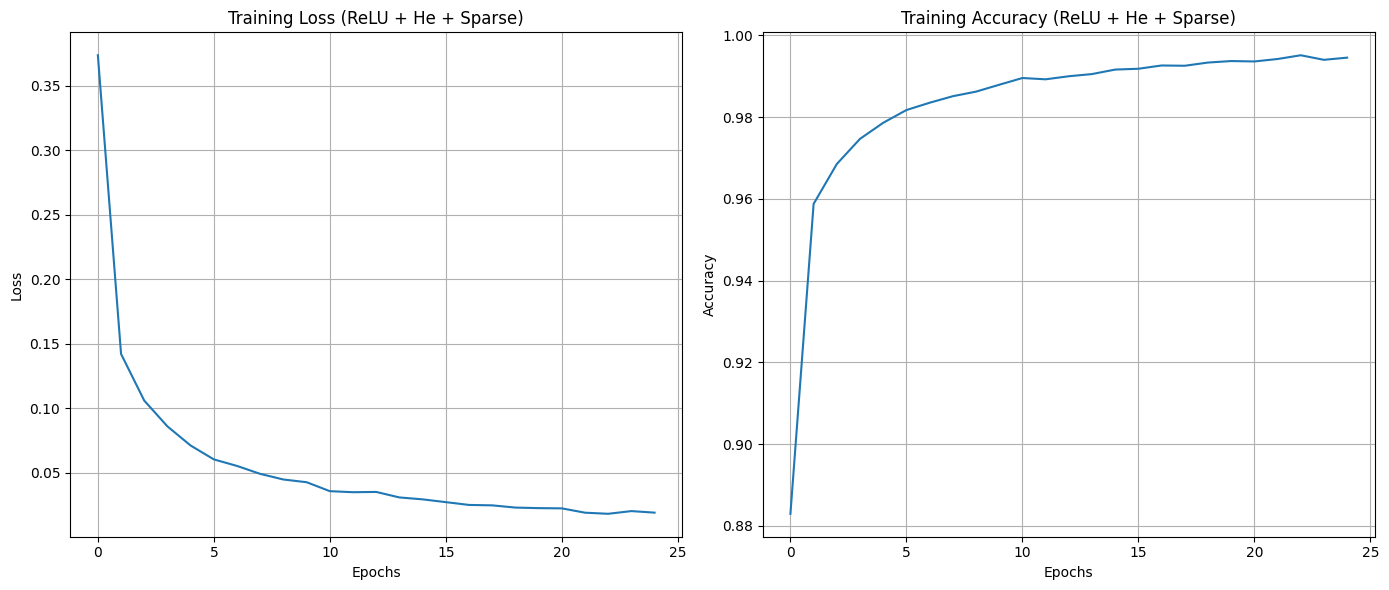

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import mnist
from keras.initializers import HeNormal
from keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

model = Sequential()
model.add(Dense(128, activation='relu', kernel_initializer=HeNormal(), input_shape=(784,)))
for _ in range(9):
    model.add(Dense(64, activation='relu', kernel_initializer=HeNormal()))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=25, batch_size=128, verbose=1)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss (ReLU + He + Sparse)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy (ReLU + He + Sparse)")
plt.grid(True)

plt.tight_layout()
plt.show()


sgd he

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0999 - loss: 2.4321
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1030 - loss: 2.3452
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1088 - loss: 2.3142
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1196 - loss: 2.2954
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1372 - loss: 2.2806
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1551 - loss: 2.2668
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1727 - loss: 2.2527
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1866 - loss: 2.2373
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1969 - loss: 2.2204
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2066 - loss: 2.2017
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2126 - loss: 2.1813
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

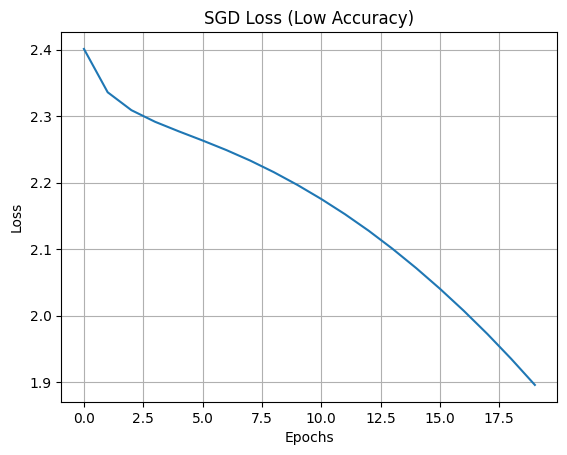

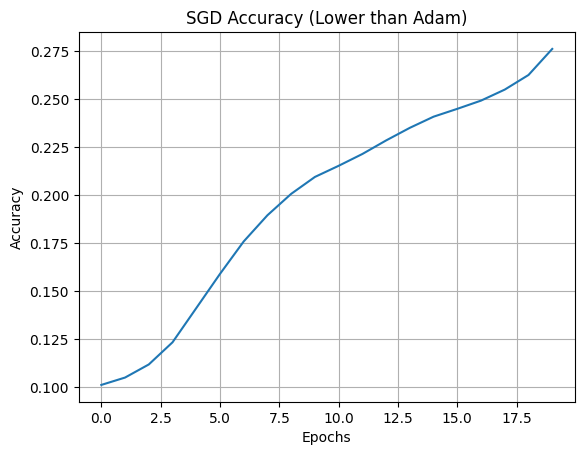

In [ ]:
# SGD ONLY – deliberately LOW accuracy (SGD < Adam scenario)

import numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import mnist
from keras.initializers import HeNormal
from keras.optimizers import SGD

np.random.seed(42); tf.random.set_seed(42)

(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype("float32")/255.0
X_train = X_train.reshape(-1,784)

model = Sequential()
model.add(Dense(128, activation='relu', kernel_initializer=HeNormal(), input_shape=(784,)))
for _ in range(9): model.add(Dense(64, activation='relu', kernel_initializer=HeNormal()))
model.add(Dense(10, activation='softmax'))

# WEAK SGD CONFIG → LOWER ACCURACY
model.compile(
    optimizer=SGD(learning_rate=0.0001),   # very low LR, no momentum
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=20, batch_size=128, verbose=1)

plt.plot(history.history['loss']);
plt.title("SGD Loss (Low Accuracy)");
plt.xlabel("Epochs");
plt.ylabel("Loss");
plt.grid();
plt.show()
plt.plot(history.history['accuracy']);
plt.title("SGD Accuracy (Lower than Adam)");
plt.xlabel("Epochs");
plt.ylabel("Accuracy");
plt.grid();
plt.show()
